# 03. GeoJSON Clipping and Boolean Masks
This notebook demonstrates how to crop a raster using a GeoJSON polygon and apply conditional spectral masking.

In [1]:
import curaster
import json
import os
import numpy as np
import matplotlib.pyplot as plt

input_file = "../build/benchmark_data/test_S_2048x2048.tif"
info = curaster.open(input_file).get_info()

## Define GeoJSON Polygon
We create a simple bounding box polygon based on the raster's extent.

In [2]:
gt = info["geotransform"]
width, height = info["width"], info["height"]

# Calculate a box in the middle of the raster
x0 = gt[0] + gt[1] * (width * 0.25)
x1 = gt[0] + gt[1] * (width * 0.75)
y0 = gt[3] + gt[5] * (height * 0.25)
y1 = gt[3] + gt[5] * (height * 0.75)

# GeoJSON Polygon: coordinates = [ [ [x,y], ... ] ]  (array of rings, each ring is array of [x,y] pairs)
aoi = json.dumps({
    "type": "Polygon",
    "coordinates": [[
        [x0, y0], [x1, y0], [x1, y1], [x0, y1], [x0, y0]
    ]]
})

## Apply Clip and Mask
We clip the image, and then use `.algebra()` to set pixels below a threshold to 0.0.

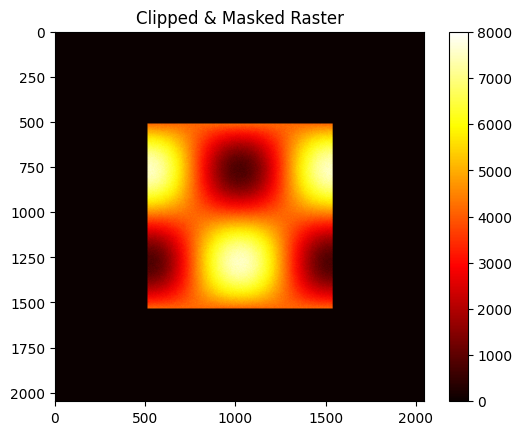

CPU times: user 777 ms, sys: 359 ms, total: 1.14 s
Wall time: 1.05 s


In [3]:
%%time
chain = curaster.open(input_file) \
    .clip(aoi) \
    .algebra("(B1 > 5000) * B1")  # Keep pixels > 5000, else 0

result = chain.to_memory()
arr = result.data()

plt.imshow(arr, cmap="hot")
plt.title("Clipped & Masked Raster")
plt.colorbar()
plt.show()